In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import Subset
from PIL import Image

# Use the relative path we discussed
train_dir = "data/train"
test_dir = "data/test"
emotions = sorted(os.listdir(train_dir))

In [2]:
# Define the RGB transformation logic
eda_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1))
])

# Load and Split
full_dataset = datasets.ImageFolder(root='data/train', transform=eda_transform)
train_idx, val_idx = train_test_split(
    range(len(full_dataset)), 
    test_size=0.2, 
    stratify=full_dataset.targets, 
    random_state=42
)

train_data = Subset(full_dataset, train_idx)
val_data = Subset(full_dataset, val_idx)

Class Balance Analysis

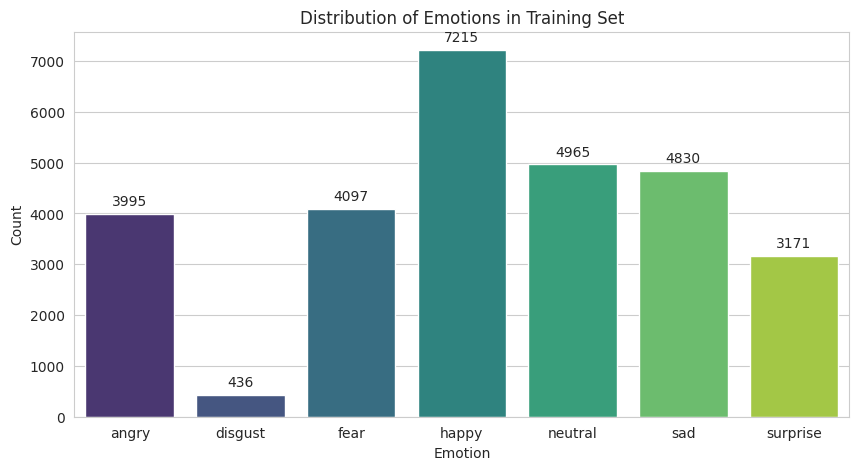

In [4]:
# 1. Count images in each emotion folder
train_counts = {em: len(os.listdir(os.path.join(train_dir, em))) for em in emotions}

# 2. Convert to a table (DataFrame)
df = pd.DataFrame(list(train_counts.items()), columns=['Emotion', 'Count'])

# 3. Create the plot
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
# Updated line to avoid the FutureWarning
bar_plot = sns.barplot(x='Emotion', y='Count', data=df, hue='Emotion', palette='viridis', legend=False)

# Add labels on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Distribution of Emotions in Training Set')
plt.show()

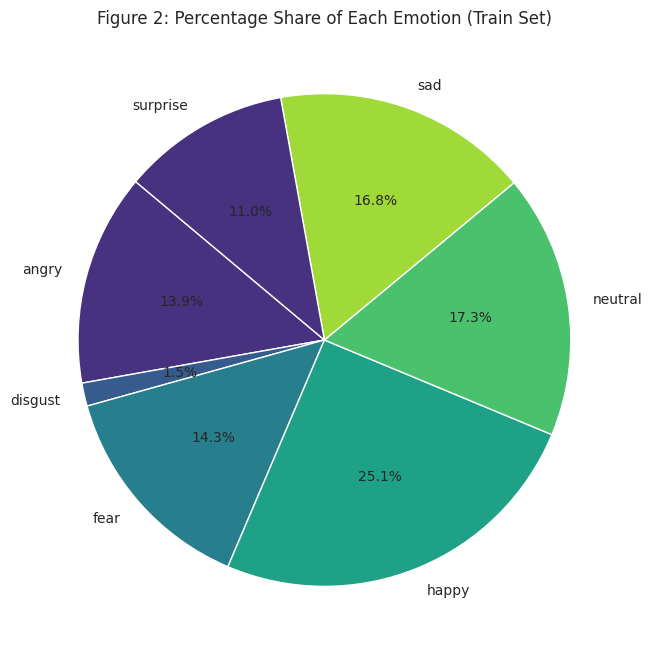

In [5]:
# Plot #2: Pie Chart of Class Distribution
plt.figure(figsize=(8, 8))
plt.pie(df['Count'], labels=df['Emotion'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Figure 2: Percentage Share of Each Emotion (Train Set)')
plt.show()

Class Balance Analysis Insight:
The dataset is highly imbalanced. Happiness (7,215 images) makes up ~25% of the data, while Disgust (436 images) makes up only ~1.5%.

Impact on Model: If we train the model without addressing this, it will likely achieve high overall accuracy by simply over-predicting "Happy" while failing to identify "Disgust" or "Fear" entirely.

Proposed Solution: We must use Data Augmentation on the minority classes and consider a Weighted Cross-Entropy Loss during the training phase to penalize the model more for missing rare emotions.

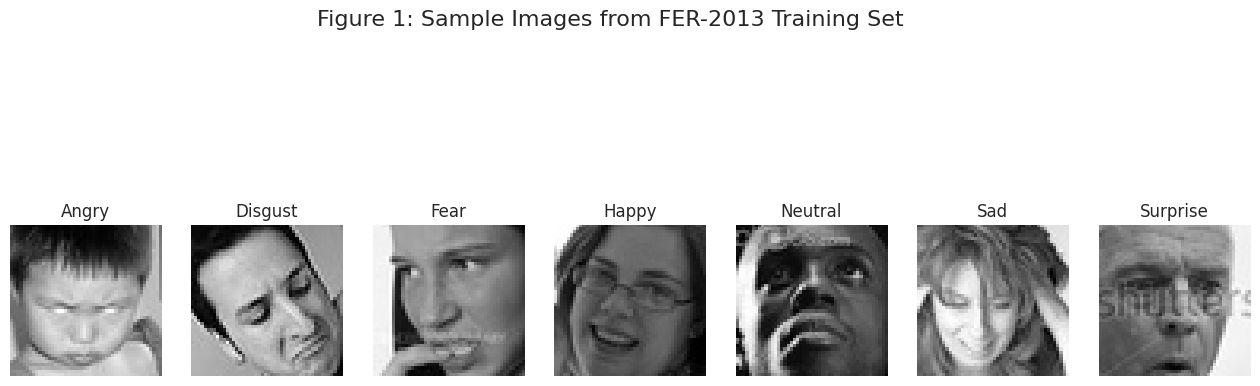

In [6]:
plt.figure(figsize=(16, 6))

for i, emotion in enumerate(emotions):
    folder = os.path.join(train_dir, emotion)
    img_name = os.listdir(folder)[0] # Get the first image in each folder
    img_path = os.path.join(folder, img_name)
    
    img = Image.open(img_path)
    plt.subplot(1, 7, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{emotion.capitalize()}")
    plt.axis('off')

plt.suptitle("Figure 1: Sample Images from FER-2013 Training Set", fontsize=16)
plt.show()

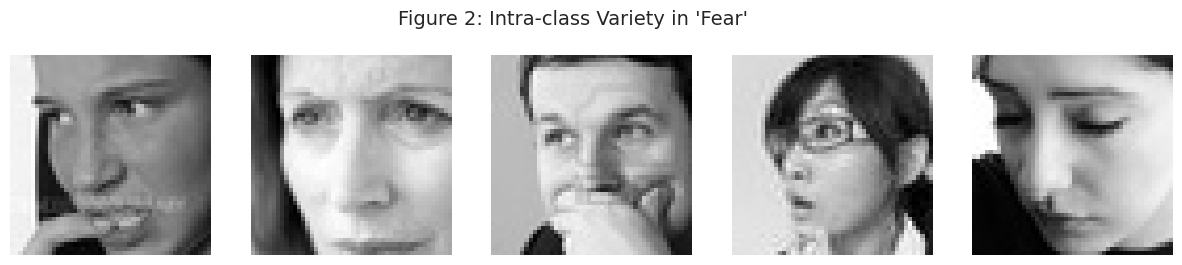

In [7]:
# Plot #3: Variety Grid for a single emotion
def plot_emotion_variety(emotion, num=5, fig_num=3):
    folder = os.path.join(train_dir, emotion)
    files = os.listdir(folder)[:num]
    
    plt.figure(figsize=(15, 3))
    for i, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        plt.subplot(1, num, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.suptitle(f"Figure {fig_num}: Intra-class Variety in '{emotion.capitalize()}'", fontsize=14)
    plt.show()

plot_emotion_variety('fear',5,2)

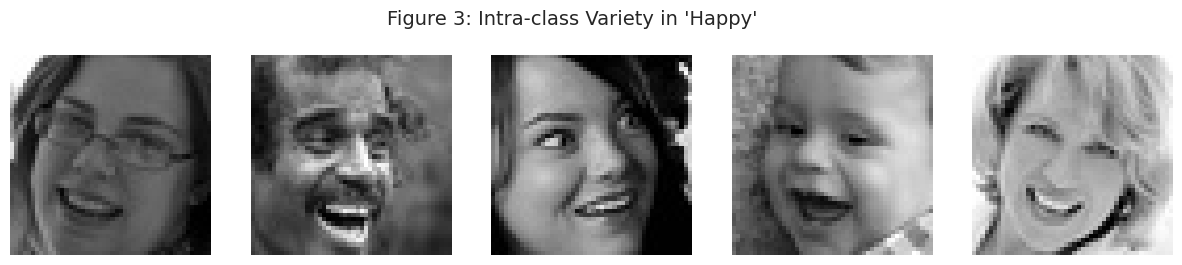

In [8]:
# Plot #4: Variety Grid for Happy
plot_emotion_variety('happy',5,3)

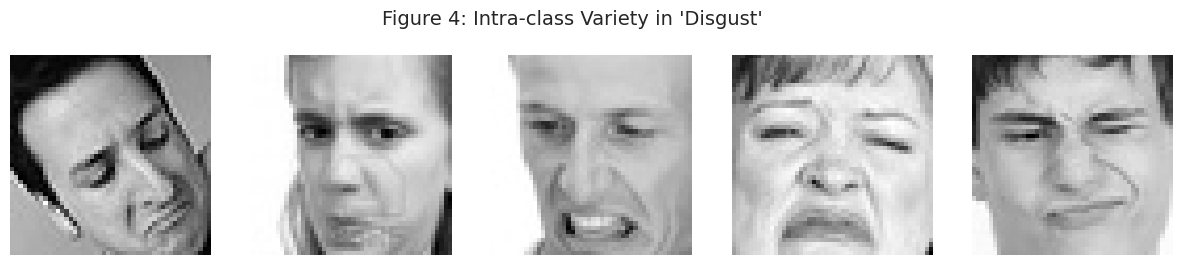

In [9]:
plot_emotion_variety('disgust',5,4)

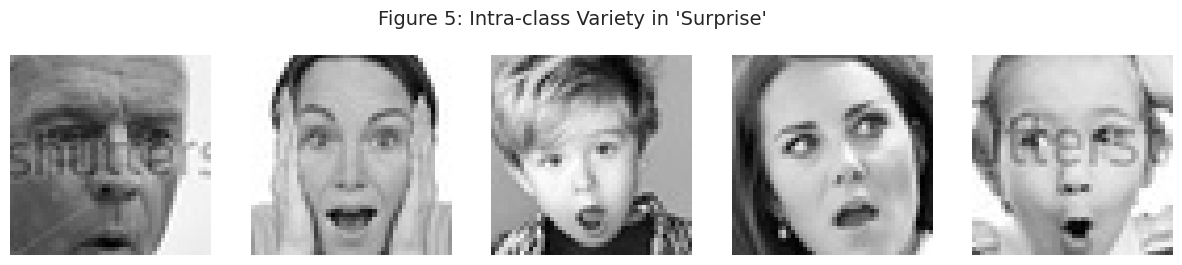

In [10]:
plot_emotion_variety('surprise',5,5)

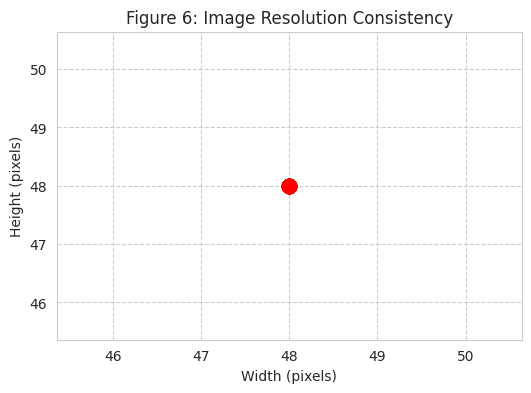

Verified: All images are 48x48 pixels.


In [11]:
# Check properties of 100 random images
dims = []
for emotion in emotions:
    folder = os.path.join(train_dir, emotion)
    for img_name in os.listdir(folder)[:20]:
        with Image.open(os.path.join(folder, img_name)) as img:
            dims.append(img.size)

# Create a scatter plot of widths vs heights
widths, heights = zip(*dims)
plt.figure(figsize=(6, 4))
plt.scatter(widths, heights, alpha=0.5, s=100, color='red')
plt.title("Figure 6: Image Resolution Consistency")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True, linestyle='--')
plt.show()

print(f"Verified: All images are {dims[0][0]}x{dims[0][1]} pixels.")

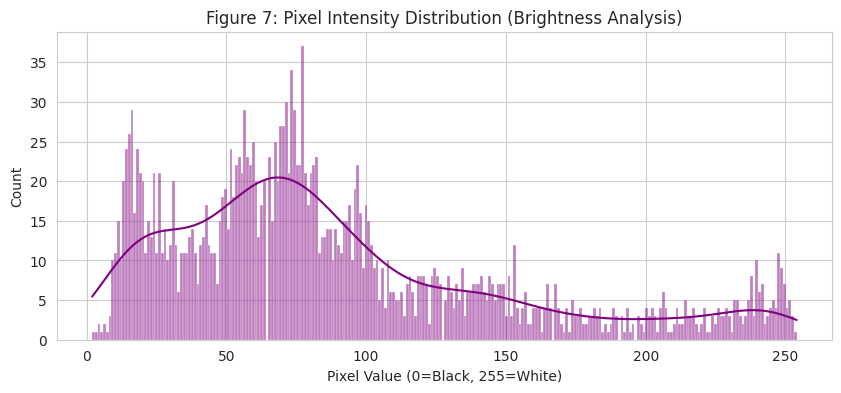

In [12]:
# Plot #5: Histogram of brightness across a sample
sample_img = np.array(Image.open(os.path.join(train_dir, 'neutral', os.listdir(os.path.join(train_dir, 'neutral'))[0])))
plt.figure(figsize=(10, 4))
sns.histplot(sample_img.ravel(), bins=256, kde=True, color='purple')
plt.title("Figure 7: Pixel Intensity Distribution (Brightness Analysis)")
plt.xlabel("Pixel Value (0=Black, 255=White)")
plt.show()

In [13]:
# Plot #8: Side-by-Side Comparison
df['Set'] = 'Train'
df_test['Set'] = 'Test'
combined = pd.concat([df[['Emotion', 'Count', 'Set']], df_test[['Emotion', 'Count', 'Set']]])

plt.figure(figsize=(12, 6))
sns.barplot(data=combined, x='Emotion', y='Count', hue='Set')
plt.title("Figure 8: Dataset Split Consistency (Train vs Test)")
plt.show()

NameError: name 'df_test' is not defined

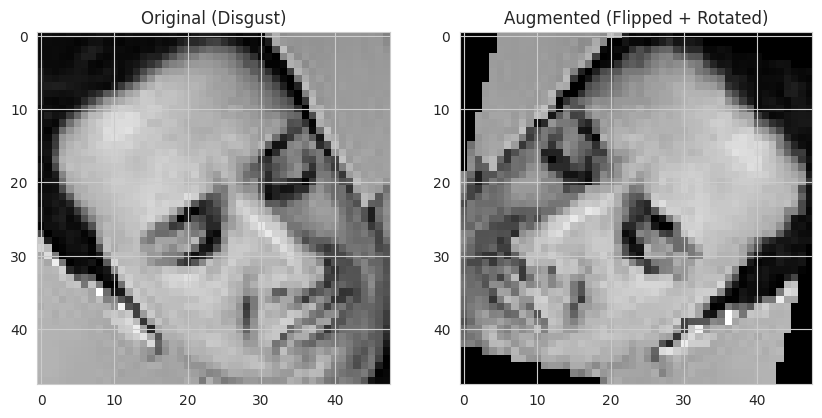

In [ ]:
from torchvision import transforms

# Define a simple transformation (Horizontal Flip + Rotation)
test_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(15),
])

# Pick one 'Disgust' image to transform
folder = os.path.join(train_dir, 'disgust')
img = Image.open(os.path.join(folder, os.listdir(folder)[0]))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original (Disgust)")

plt.subplot(1, 2, 2)
plt.imshow(test_transform(img), cmap='gray')
plt.title("Augmented (Flipped + Rotated)")
plt.show()